In [25]:
# ============================================================
# VISUALIZE CAMS DATA - PM2.5
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Excel file location
# ------------------------------------------------------------

INPUT_FILE = r"C:/Users/Juvair/Desktop/Job Application CV's/BUET_RA/Dataset/Air Pollution Dataset/CAMS_CleanDataset/Renamed/CAMS_All_Stations.xlsx"


In [26]:
# ------------------------------------------------------------
# 2. Read the Excel file
# ------------------------------------------------------------

df = pd.read_excel(INPUT_FILE)

# ------------------------------------------------------------
# 3. Convert CalendarDate to date format
# ------------------------------------------------------------

df["CalendarDate"] = pd.to_datetime(df["CalendarDate"])

In [33]:
# ------------------------------------------------------------
# 4. See the data
# ------------------------------------------------------------

print("Number of rows:", len(df))

print("\nCAMS Stations:")
print(df["CAMS_Station"].unique())

print("\nFirst 5 rows:")
print(df.head())


Number of rows: 17449

CAMS Stations:
['Chittagong_Agrabad' 'Chittagong_Khulshi' 'Cumilla' 'Dhaka_BARC'
 'Dhaka_DarusSalam' 'Gazipur' 'Khulna' 'Mymensingh' 'Narayanganj'
 'Narsingdi' 'Rajshahi' 'Rangpur' 'Savar']

First 5 rows:
  CalendarDate        CAMS_Station  SO2_daily_avg  NO_daily_avg  \
0   2012-11-01  Chittagong_Agrabad       0.387143      3.818824   
1   2012-11-02  Chittagong_Agrabad       0.140000     12.406429   
2   2012-11-03  Chittagong_Agrabad       0.056667      2.007826   
3   2012-11-04  Chittagong_Agrabad       0.035000      4.373750   
4   2012-11-05  Chittagong_Agrabad       0.292857     12.615652   

   NO2_daily_avg  NOX_daily_avg  CO_daily_avg  CO8hr_daily_avg  O3_daily_avg  \
0       4.949167       7.934783      0.607083         0.549191      2.723478   
1       4.708000      15.477647      0.664783         0.684583      3.462632   
2       5.911667       7.870417      0.507917         0.514635      3.591667   
3       5.375000      10.089545      0.348000    

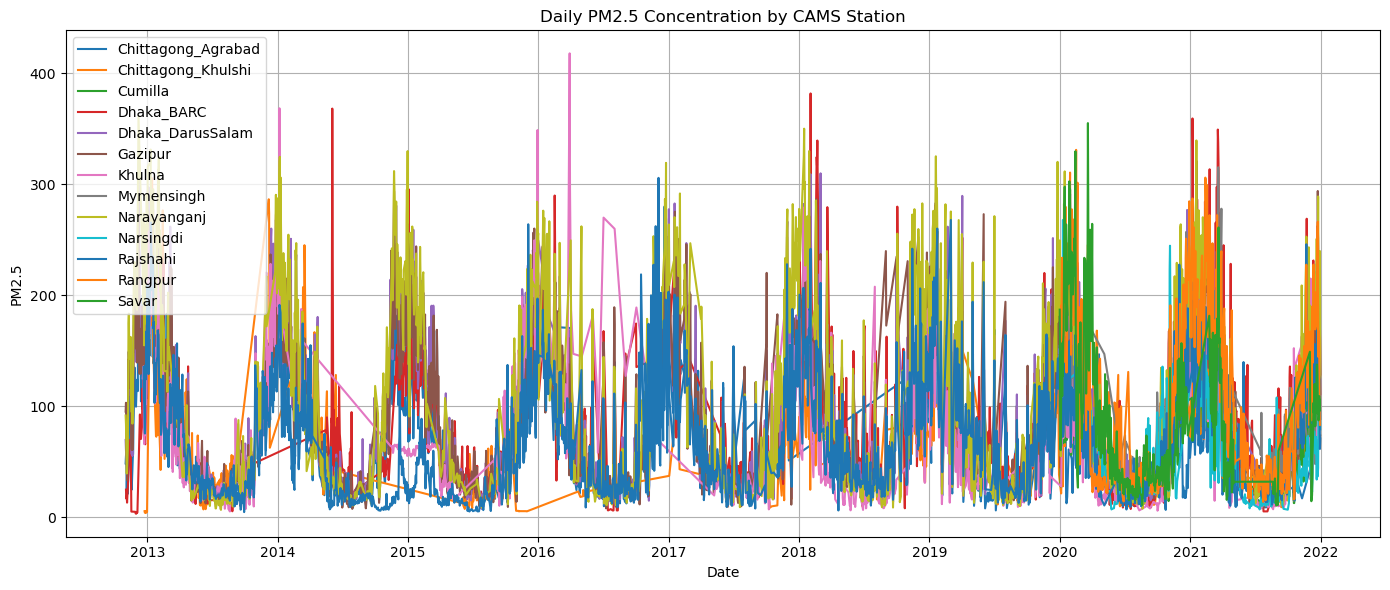

In [44]:
# ------------------------------------------------------------
# 5. Plot PM2.5
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

# Plot each station separately
for station in df["CAMS_Station"].unique():

    station_data = df[df["CAMS_Station"] == station]

    plt.plot(
        station_data["CalendarDate"],
        station_data["PM25_daily_avg"],
        label=station
    )

# ------------------------------------------------------------
# 6. Add labels and title
# ------------------------------------------------------------

plt.title("Daily PM2.5 Concentration by CAMS Station")

plt.xlabel("Date")

plt.ylabel("PM2.5")

plt.legend()

plt.grid(True)

plt.tight_layout()

# ------------------------------------------------------------
# 7. Display the graph
# ------------------------------------------------------------

plt.show()


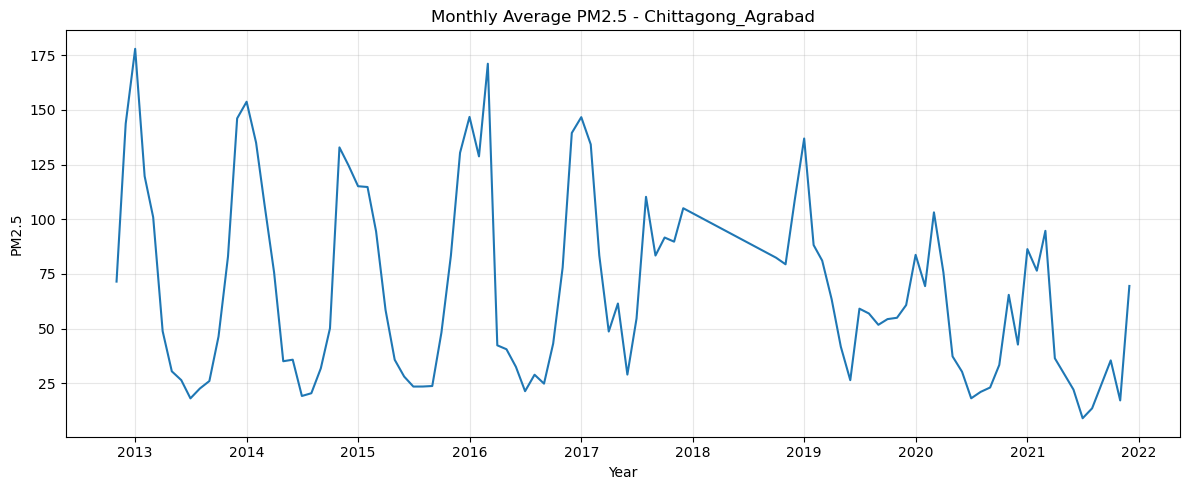

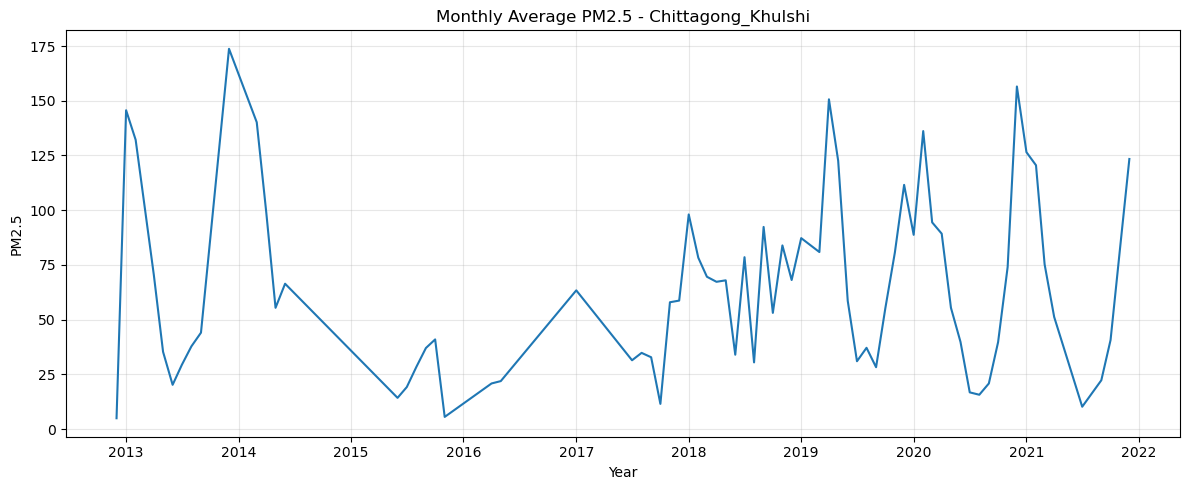

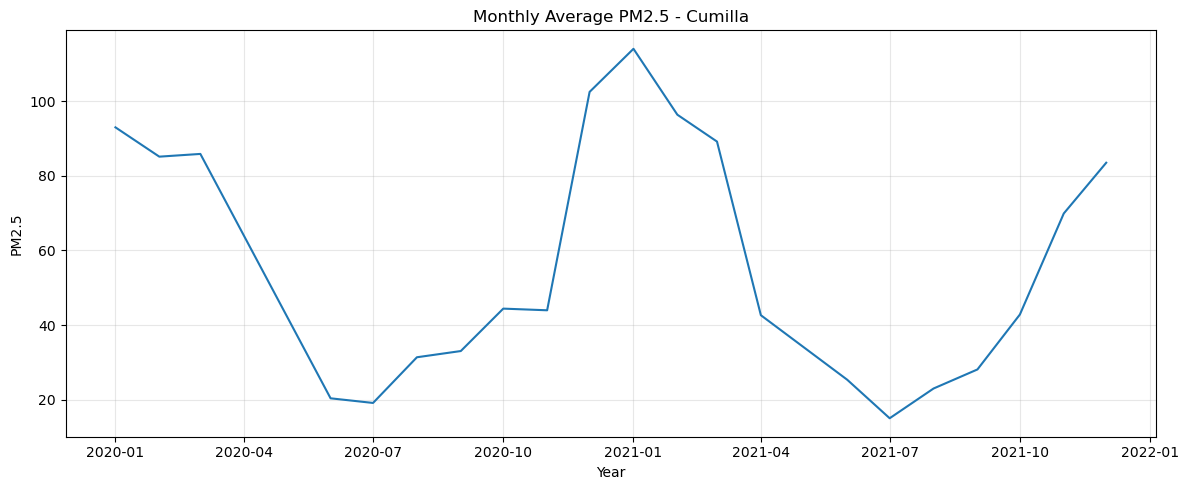

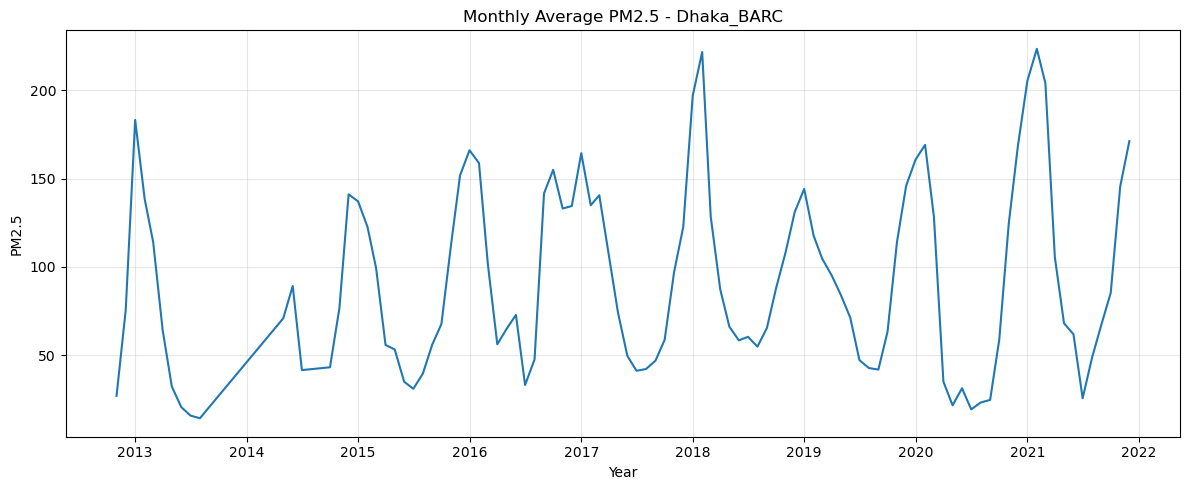

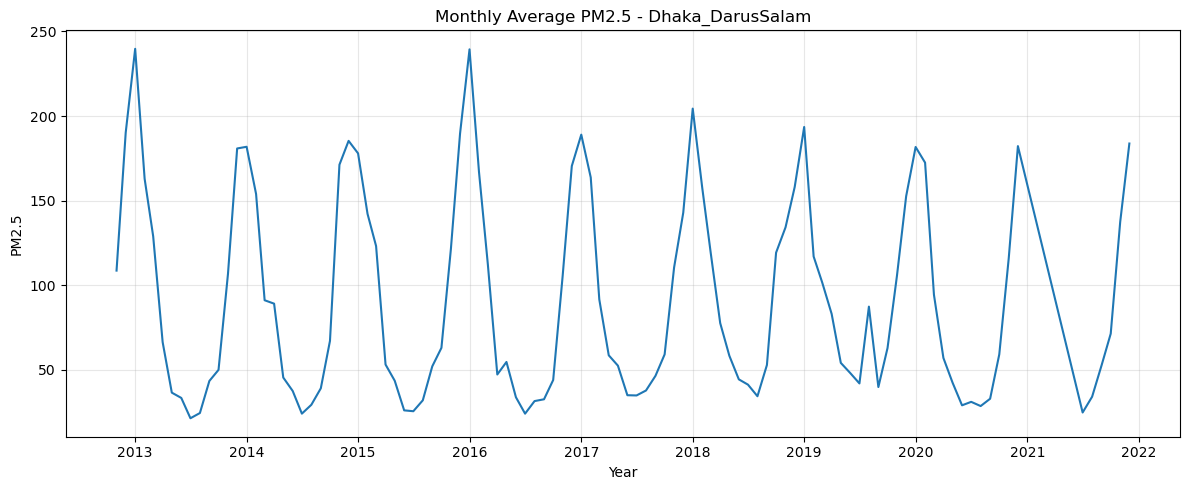

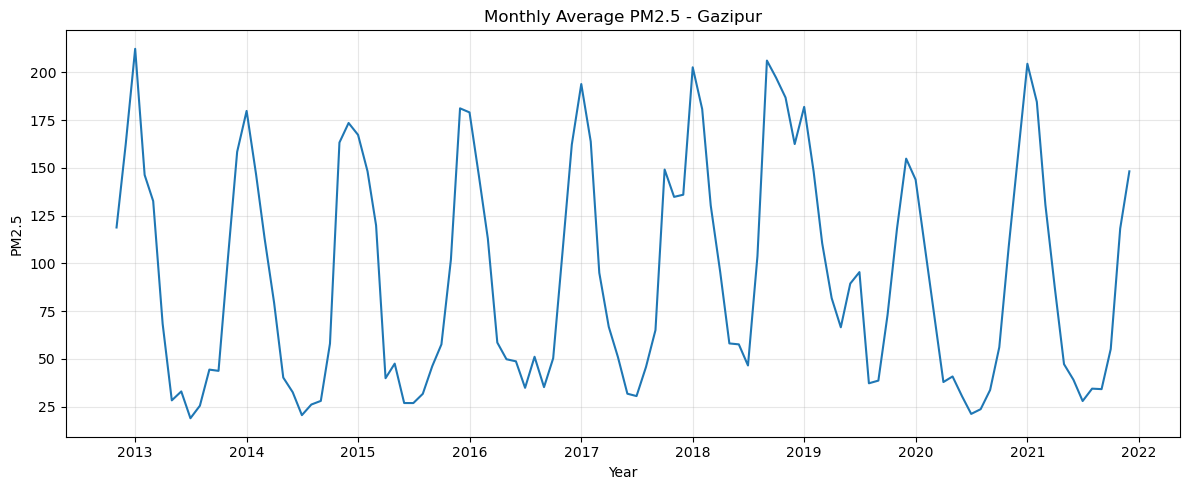

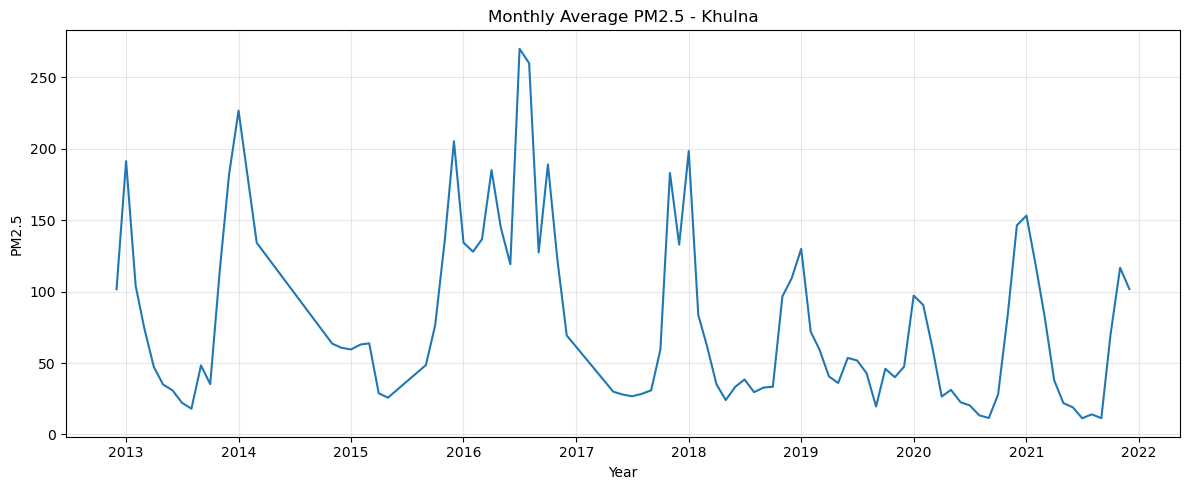

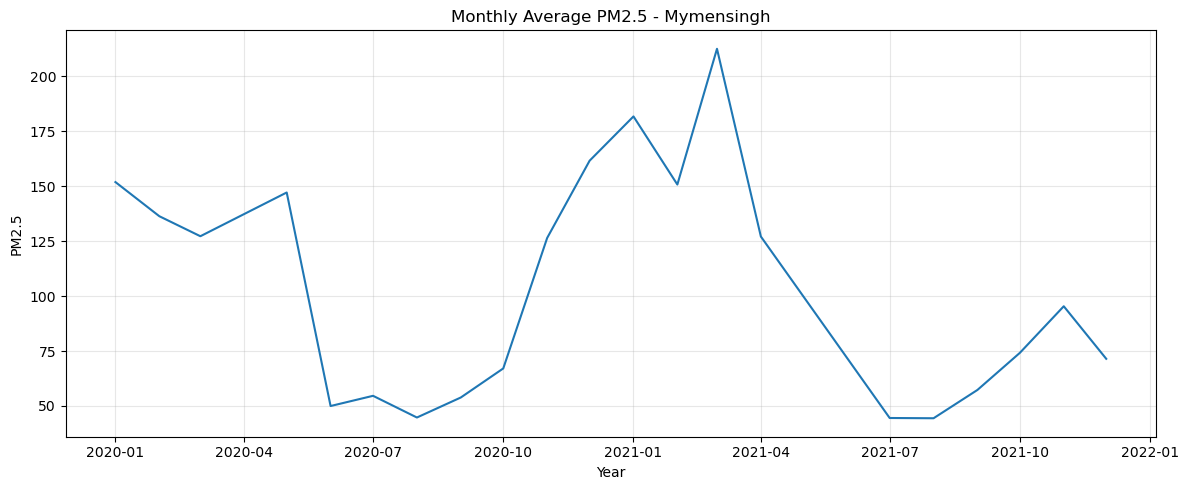

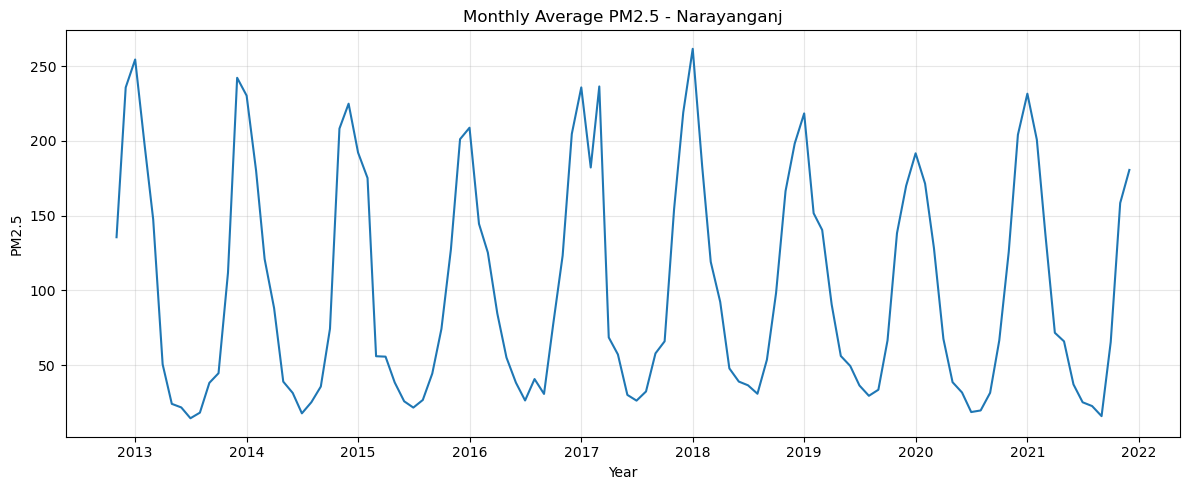

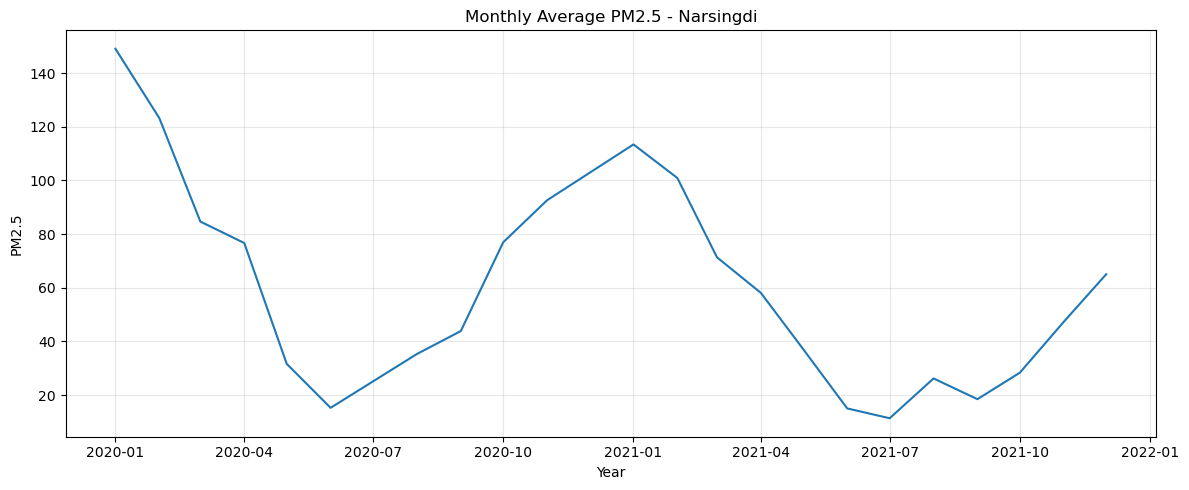

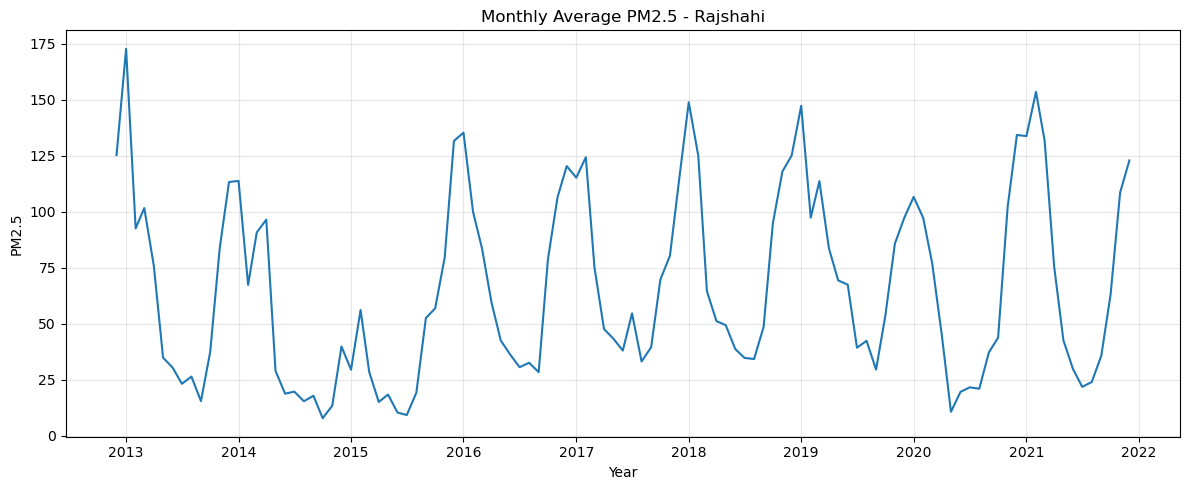

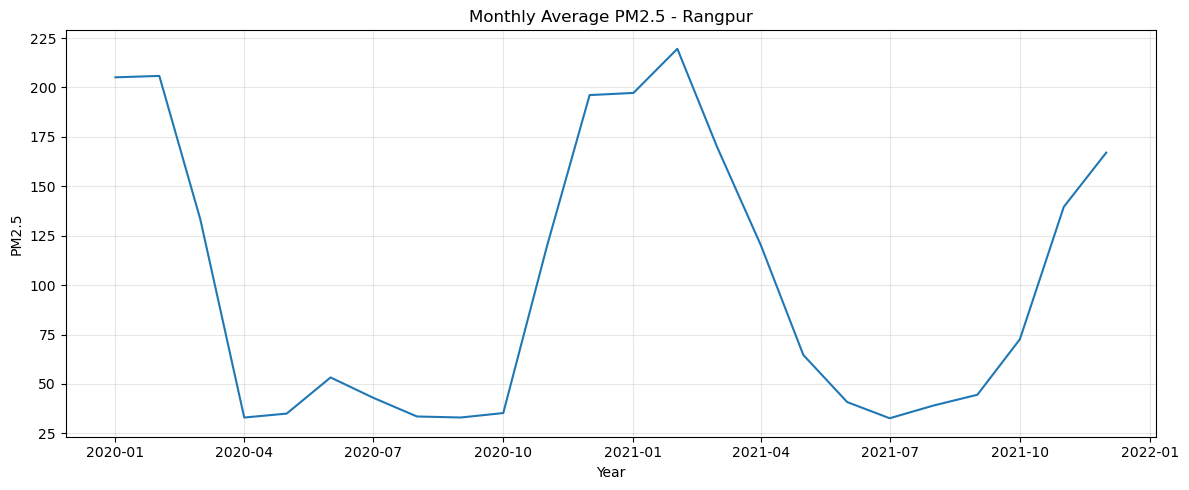

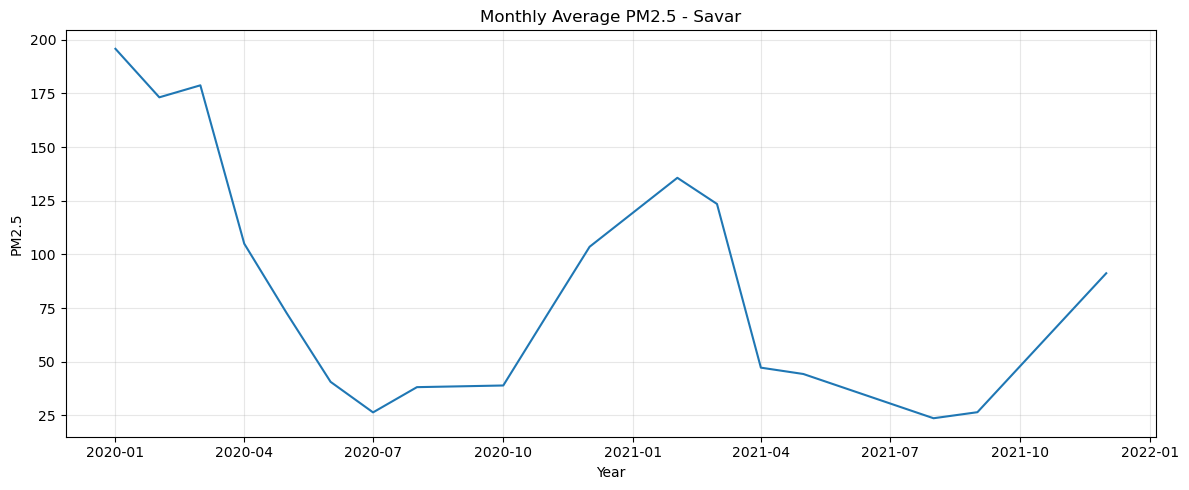

In [48]:
# ============================================================
# VISUALIZE CAMS DATA - MONTHLY PM2.5
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Excel file
# ------------------------------------------------------------

INPUT_FILE = r"C:/Users/Juvair/Desktop/Job Application CV's/BUET_RA/Dataset/Air Pollution Dataset/CAMS_CleanDataset/Renamed/CAMS_All_Stations.xlsx"

# ------------------------------------------------------------
# 2. Read Excel
# ------------------------------------------------------------

df = pd.read_excel(INPUT_FILE)

# Convert date
df["CalendarDate"] = pd.to_datetime(df["CalendarDate"])

# ------------------------------------------------------------
# 3. Create Year-Month column
# ------------------------------------------------------------

df["YearMonth"] = df["CalendarDate"].dt.to_period("M")

# ------------------------------------------------------------
# 4. Calculate monthly average PM2.5
# ------------------------------------------------------------

monthly_pm25 = (
    df.groupby(["CAMS_Station", "YearMonth"])["PM25_daily_avg"]
      .mean()
      .reset_index()
)

# Convert YearMonth back to date
monthly_pm25["YearMonth"] = monthly_pm25["YearMonth"].dt.to_timestamp()

# ------------------------------------------------------------
# 5. Create ONE graph for each station
# ------------------------------------------------------------

for station in monthly_pm25["CAMS_Station"].unique():

    station_data = monthly_pm25[
        monthly_pm25["CAMS_Station"] == station
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        station_data["YearMonth"],
        station_data["PM25_daily_avg"],
        linewidth=1.5
    )

    plt.title(
        f"Monthly Average PM2.5 - {station}"
    )

    plt.xlabel("Year")

    plt.ylabel("PM2.5")

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

Part-02

In [50]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Load Data
filepath = r"C:/Users/Juvair/Desktop/Job Application CV's/BUET_RA/Dataset/Air Pollution Dataset/CAMS_CleanDataset/Renamed/CAMS_All_Stations.xlsx"
df = pd.read_excel(filepath, sheet_name='Sheet1')

# Convert date column and extract temporal features
df['CalendarDate'] = pd.to_datetime(df['CalendarDate'])
df['Year'] = df['CalendarDate'].dt.year
df['Month'] = df['CalendarDate'].dt.month

# Define Season based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Pre-Monsoon'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(get_season)

# Map stations to primary cities
station_city_map = {
    'Chittagong_Agrabad': 'Chattogram',
    'Chittagong_Khulshi': 'Chattogram_Khulshi',
    'Cumilla': 'Cumilla',
    'Dhaka_BARC': 'Dhaka_BARC',
    'Dhaka_DarusSalam': 'Dhaka',
    'Gazipur': 'Gazipur',
    'Khulna': 'Khulna',
    'Mymensingh': 'Mymensingh',
    'Narayanganj': 'Narayanganj',
    'Narsingdi': 'Narsingdi',
    'Rajshahi': 'Rajshahi',
    'Rangpur': 'Rangpur',
    'Savar': 'Savar'
}
df['City'] = df['CAMS_Station'].map(station_city_map)

pollutants = ['PM25_daily_avg', 'PM10_daily_avg', 'SO2_daily_avg', 'NO2_daily_avg', 'CO_daily_avg', 'O3_daily_avg']

In [51]:
# ---------------------------------------------------------
# 2. Data Quality / Completeness Check
# ---------------------------------------------------------
completeness_summary = pd.DataFrame({
    'Valid_Count': df[pollutants].count(),
    'Missing_Count': df[pollutants].isnull().sum(),
    'Completeness_Pct': (df[pollutants].count() / len(df) * 100).round(2)
})
print("--- Data Completeness Summary ---")
print(completeness_summary)

station_completeness = df.groupby('CAMS_Station')[pollutants].apply(lambda x: x.notnull().mean() * 100).round(1)
print("\n--- Station-wise Pollutant Completeness (%) ---")
print(station_completeness)

--- Data Completeness Summary ---
                Valid_Count  Missing_Count  Completeness_Pct
PM25_daily_avg        17449              0            100.00
PM10_daily_avg        15271           2178             87.52
SO2_daily_avg         13848           3601             79.36
NO2_daily_avg         12649           4800             72.49
CO_daily_avg          13707           3742             78.55
O3_daily_avg          14176           3273             81.24

--- Station-wise Pollutant Completeness (%) ---
                    PM25_daily_avg  PM10_daily_avg  SO2_daily_avg  \
CAMS_Station                                                        
Chittagong_Agrabad           100.0            90.9           80.9   
Chittagong_Khulshi           100.0            93.8           87.8   
Cumilla                      100.0            99.5           68.3   
Dhaka_BARC                   100.0            87.0           84.1   
Dhaka_DarusSalam             100.0            96.2           81.6   
Gazipur

In [52]:
# ---------------------------------------------------------
# 3. Descriptive Statistics
# ---------------------------------------------------------
desc_stats = df[pollutants].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
print("\n--- Overall Descriptive Statistics ---")
print(desc_stats.round(2))

# ---------------------------------------------------------
# 4. Monthly & Seasonal Analysis
# ---------------------------------------------------------
seasonal_pm25 = df.groupby('Season')['PM25_daily_avg'].agg(['mean', 'std', 'median']).loc[['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon']]
print("\n--- Seasonal PM2.5 Statistics ---")
print(seasonal_pm25.round(2))

monthly_pm25 = df.groupby('Month')['PM25_daily_avg'].mean()
print("\n--- Monthly Mean PM2.5 ---")
print(monthly_pm25.round(2))


--- Overall Descriptive Statistics ---
                  mean     std   min    25%     50%     75%     max     IQR
PM25_daily_avg   84.56   64.69  3.32  32.09   64.41  124.26  417.79   92.17
PM10_daily_avg  149.88  107.03  2.66  63.76  122.54  212.87  968.67  149.11
SO2_daily_avg     7.15   12.55  0.01   1.51    3.47    8.04  249.45    6.54
NO2_daily_avg    14.42   16.49  0.04   3.43    9.64   19.55  202.29   16.11
CO_daily_avg      1.40    1.18  0.01   0.60    1.09    1.86   25.49    1.26
O3_daily_avg      9.94   10.34  0.05   3.01    6.80   13.38  124.37   10.37

--- Seasonal PM2.5 Statistics ---
                mean    std  median
Season                             
Winter        146.88  62.02  143.31
Pre-Monsoon    75.16  49.12   62.56
Monsoon        34.06  25.00   27.48
Post-Monsoon   83.96  50.63   75.04

--- Monthly Mean PM2.5 ---
Month
1     162.32
2     135.32
3     108.33
4      65.40
5      46.23
6      36.72
7      29.12
8      31.19
9      39.17
10     58.76
11    106.47


In [53]:
# ---------------------------------------------------------
# 5. City-to-City / Station Comparison
# ---------------------------------------------------------
station_comp = df.groupby('CAMS_Station')[['PM25_daily_avg', 'PM10_daily_avg', 'SO2_daily_avg', 'NO2_daily_avg']].mean().sort_values('PM25_daily_avg', ascending=False)
print("\n--- Station-level Mean Pollutant Concentration ---")
print(station_comp.round(2))

city_comp = df.groupby('City')[['PM25_daily_avg', 'PM10_daily_avg', 'SO2_daily_avg', 'NO2_daily_avg']].mean().sort_values('PM25_daily_avg', ascending=False)
print("\n--- City-level Mean Pollutant Concentration ---")
print(city_comp.round(2))

# ---------------------------------------------------------
# 6. Exceedance Analysis
# ---------------------------------------------------------
# Standards: BD PM2.5 = 65, WHO PM2.5 = 15, BD PM10 = 150
exceed_bd_pm25 = df.groupby('CAMS_Station')['PM25_daily_avg'].apply(lambda x: (x > 65).mean() * 100).round(1)
exceed_who_pm25 = df.groupby('CAMS_Station')['PM25_daily_avg'].apply(lambda x: (x > 15).mean() * 100).round(1)
exceed_bd_pm10 = df.groupby('CAMS_Station')['PM10_daily_avg'].apply(lambda x: (x > 150).mean() * 100).round(1)

exceedance_df = pd.DataFrame({
    'PM2.5_Exceed_BD_65_Pct': exceed_bd_pm25,
    'PM2.5_Exceed_WHO_15_Pct': exceed_who_pm25,
    'PM10_Exceed_BD_150_Pct': exceed_bd_pm10
})
print("\n--- Exceedance Rates (%) ---")
print(exceedance_df)


--- Station-level Mean Pollutant Concentration ---
                    PM25_daily_avg  PM10_daily_avg  SO2_daily_avg  \
CAMS_Station                                                        
Mymensingh                  108.11          169.17           2.91   
Rangpur                     107.16          171.67           5.31   
Narayanganj                 102.18          204.61          10.18   
Gazipur                      97.96          169.24           9.70   
Dhaka_BARC                   91.27          143.68           6.58   
Savar                        90.88          111.66           6.60   
Dhaka_DarusSalam             87.04          148.48           9.40   
Khulna                       77.58          124.29           5.70   
Chittagong_Agrabad           74.93          141.71           5.38   
Rajshahi                     67.33          146.63           6.39   
Chittagong_Khulshi           63.52          102.39           8.71   
Narsingdi                    63.37          108.74 

In [54]:
# ---------------------------------------------------------
# 7. AQI/Standard-Based Classification
# ---------------------------------------------------------
def classify_pm25_aqi(pm):
    if pd.isna(pm):
        return np.nan
    elif pm <= 12.0:
        return 'Good'
    elif pm <= 35.4:
        return 'Moderate'
    elif pm <= 55.4:
        return 'Cautionary'
    elif pm <= 150.4:
        return 'Unhealthy'
    elif pm <= 250.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['AQI_Category'] = df['PM25_daily_avg'].apply(classify_pm25_aqi)
aqi_order = ['Good', 'Moderate', 'Cautionary', 'Unhealthy', 'Very Unhealthy', 'Hazardous']

aqi_dist = (df.groupby('CAMS_Station')['AQI_Category']
            .value_counts(normalize=True)
            .unstack()
            .reindex(columns=aqi_order)
            .fillna(0) * 100).round(1)

print("\n--- Station AQI Category Distribution (%) ---")
print(aqi_dist)



--- Station AQI Category Distribution (%) ---
AQI_Category        Good  Moderate  Cautionary  Unhealthy  Very Unhealthy  \
CAMS_Station                                                                
Chittagong_Agrabad   1.3      30.9        12.9       44.9             9.8   
Chittagong_Khulshi   5.9      28.0        16.4       44.4             4.9   
Cumilla              0.3      30.4        17.3       51.0             1.0   
Dhaka_BARC           1.8      16.9        19.1       45.2            15.1   
Dhaka_DarusSalam     0.3      26.2        20.5       33.3            16.9   
Gazipur              1.8      22.4        13.7       37.2            23.1   
Khulna               5.4      26.4        12.4       42.5            11.9   
Mymensingh           0.0       6.0        20.5       47.9            23.4   
Narayanganj          2.0      30.7        11.8       25.7            23.4   
Narsingdi            4.9      27.2        20.2       43.7             3.7   
Rajshahi             4.9     

In [55]:

# ---------------------------------------------------------
# 8. Trend Analysis
# ---------------------------------------------------------
annual_pm25 = df.groupby(['Year', 'CAMS_Station'])['PM25_daily_avg'].mean().unstack()
print("\n--- Annual Mean PM2.5 Concentration by Station ---")
print(annual_pm25.round(1))

# ---------------------------------------------------------
# 9. Statistical Significance Testing
# ---------------------------------------------------------
# Seasonality significance test (Kruskal-Wallis)
season_groups = [group['PM25_daily_avg'].dropna().values for name, group in df.groupby('Season')]
kw_season = stats.kruskal(*season_groups)
print(f"\nKruskal-Wallis test across Seasons: H = {kw_season.statistic:.2f}, p-value = {kw_season.pvalue:.4e}")

# Geographical significance test (Kruskal-Wallis)
station_groups = [group['PM25_daily_avg'].dropna().values for name, group in df.groupby('CAMS_Station')]
kw_station = stats.kruskal(*station_groups)
print(f"Kruskal-Wallis test across Stations: H = {kw_station.statistic:.2f}, p-value = {kw_station.pvalue:.4e}")


--- Annual Mean PM2.5 Concentration by Station ---
CAMS_Station  Chittagong_Agrabad  Chittagong_Khulshi  Cumilla  Dhaka_BARC  \
Year                                                                        
2012                       108.9                 5.0      NaN        58.2   
2013                        74.8                59.0      NaN        75.9   
2014                        88.2                89.7      NaN        89.5   
2015                        77.2                27.2      NaN        83.5   
2016                        64.1                21.7      NaN        89.4   
2017                        81.7                51.8      NaN        73.8   
2018                        95.8                71.2      NaN        97.7   
2019                        74.6                66.6      NaN        90.5   
2020                        52.9                57.6     61.5        85.7   
2021                        73.7                86.8     63.6       120.8   

CAMS_Station  Dhaka_Dar